<a href="https://colab.research.google.com/github/JavierPelao/Deep_Learning_Ev1/blob/main/Deep_Learning_Ev1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title
from IPython.display import HTML, display

url_svg = "https://upload.wikimedia.org/wikipedia/commons/a/aa/Logo_DuocUC.svg"

display(HTML(f'<img src="{url_svg}" width="300">'))

**Asignatura:** Deep Learning_004D       
**Evaluación:** Evaluación Parcial N°1  
**Integrantes:** Javier Loaiza - Fabian Romero  
**Fecha:** Septiembre 2026

# Evaluación Parcial 1 - Deep Learning

## Clasificación de imágenes con una Red Neuronal Multicapa (MLP)

### Introducción

En esta evaluación se desarrollará una red neuronal artificial multicapa (MLP) para resolver un problema de clasificación de imágenes utilizando el conjunto de datos Fashion-MNIST.

Fashion-MNIST contiene imágenes en escala de grises correspondientes a distintas categorías de prendas de vestir. A partir de estos datos, se busca entrenar una red neuronal capaz de aprender patrones presentes en las imágenes y posteriormente clasificarlas en su categoría correspondiente.

Durante el desarrollo se aplicarán conceptos estudiados en la asignatura, como funciones de activación, función de pérdida, descenso del gradiente, backpropagation, optimización y técnicas de regularización. Además, se analizará el comportamiento del modelo mediante distintas configuraciones de entrenamiento y métricas de evaluación.

### Objetivo

Implementar y entrenar una red neuronal multicapa (MLP) utilizando TensorFlow/Keras para clasificar imágenes del conjunto Fashion-MNIST, analizando el efecto de diferentes configuraciones y técnicas de entrenamiento sobre el desempeño y la capacidad de generalización del modelo.

## Carga del conjunto de datos

Para el desarrollo de la evaluación se utilizará el conjunto de datos Fashion-MNIST, disponible directamente a través de TensorFlow/Keras. El dataset contiene imágenes en escala de grises de distintas prendas de vestir, junto con la etiqueta correspondiente a cada imagen.

En esta primera etapa se cargarán los datos y se revisará su estructura antes de realizar cualquier transformación o preprocesamiento.

In [2]:
# Importar el dataset Fashion-MNIST desde Keras
from tensorflow.keras.datasets import fashion_mnist

# Cargar los conjuntos originales de entrenamiento y prueba
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Mostrar las dimensiones de los conjuntos cargados
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_test:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dimensiones de X_train: (60000, 28, 28)
Dimensiones de y_train: (60000,)
Dimensiones de X_test: (10000, 28, 28)
Dimensiones de y_test: (10000,)


### Estructura inicial de los datos

El conjunto de entrenamiento contiene 60.000 imágenes de 28×28 píxeles y 60.000 etiquetas asociadas. Por otra parte, el conjunto de prueba contiene 10.000 imágenes con sus respectivas etiquetas.

Las imágenes se encuentran almacenadas en `X_train` y `X_test`, mientras que `y_train` y `y_test` contienen las clases correspondientes a cada imagen.

El conjunto de prueba se mantendrá reservado para la evaluación final del modelo, evitando utilizarlo durante la selección y ajuste de configuraciones.

In [3]:
import numpy as np

# Revisar características básicas del conjunto de entrenamiento
print("Rango de valores de los píxeles:", X_train.min(), "-", X_train.max())
print("Tipo de dato:", X_train.dtype)
print("Clases presentes:", np.unique(y_train))
print("Cantidad de clases:", len(np.unique(y_train)))

Rango de valores de los píxeles: 0 - 255
Tipo de dato: uint8
Clases presentes: [0 1 2 3 4 5 6 7 8 9]
Cantidad de clases: 10


### Análisis inicial

Las imágenes presentan valores de píxeles en un rango de 0 a 255 y se encuentran almacenadas con tipo de dato `uint8`. Esta información será considerada posteriormente durante el preprocesamiento de los datos.

Las etiquetas corresponden a valores enteros entre 0 y 9, por lo que el problema presenta un total de 10 clases diferentes.

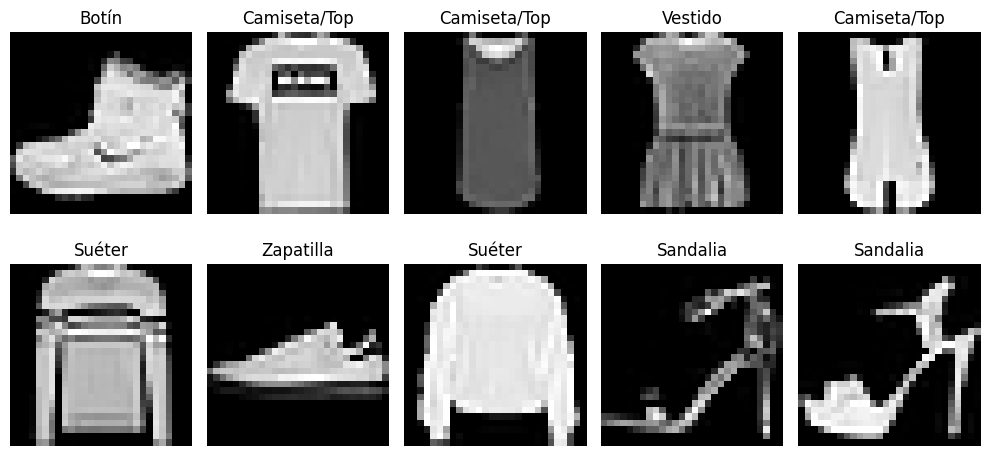

In [4]:
import matplotlib.pyplot as plt

# Nombres correspondientes a las 10 clases de Fashion-MNIST
class_names = [
    "Camiseta/Top", "Pantalón", "Suéter", "Vestido", "Abrigo",
    "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"
]

# Visualizar las primeras 10 imágenes del conjunto de entrenamiento
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Visualización de ejemplos

Se visualizaron ejemplos del conjunto de entrenamiento junto con sus respectivas etiquetas para comprender la información contenida en Fashion-MNIST. Se observa que las imágenes corresponden a prendas de vestir representadas en escala de grises y con una resolución de 28×28 píxeles.

Las etiquetas originales se encuentran codificadas mediante valores enteros entre 0 y 9, por lo que para facilitar su interpretación se asociaron con los nombres de las clases definidos en español para asi poder identificar y explicar de manera clara los resultados.

### Distribución de las clases

Antes de realizar el preprocesamiento, se revisará la cantidad de ejemplos disponibles para cada clase en el conjunto de entrenamiento. Esto permite conocer si las categorías presentan una distribución equilibrada y considerar esta información al momento de separar los datos de entrenamiento y validación.

In [5]:
# Contar la cantidad de ejemplos correspondientes a cada clase
clases, cantidades = np.unique(y_train, return_counts=True)

# Mostrar la cantidad de ejemplos por clase
for clase, cantidad in zip(clases, cantidades):
    print(f"{clase} - {class_names[clase]}: {cantidad}")

0 - Camiseta/Top: 6000
1 - Pantalón: 6000
2 - Suéter: 6000
3 - Vestido: 6000
4 - Abrigo: 6000
5 - Sandalia: 6000
6 - Camisa: 6000
7 - Zapatilla: 6000
8 - Bolso: 6000
9 - Botín: 6000


Se observa que las 10 clases tienen 6.000 imágenes cada una, por lo que el conjunto de entrenamiento se encuentra balanceado. Esto evita que alguna categoría tenga mayor representación que las demás durante el entrenamiento.

## Preprocesamiento de los datos

Antes de entrenar la red, el conjunto de entrenamiento se dividirá en datos de entrenamiento y validación. Se utilizará un 80% para entrenamiento y un 20% para validación.

El conjunto de test se mantendrá separado durante los experimentos y se utilizará únicamente para evaluar el modelo final.

In [6]:
from sklearn.model_selection import train_test_split

# Separar el conjunto original en entrenamiento (80%) y validación (20%)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Mostrar las dimensiones obtenidas
print("Entrenamiento:", X_tr.shape, y_tr.shape)
print("Validación:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Entrenamiento: (48000, 28, 28) (48000,)
Validación: (12000, 28, 28) (12000,)
Test: (10000, 28, 28) (10000,)


La división generó 48.000 imágenes para entrenamiento y 12.000 para validación, manteniendo las 10.000 imágenes originales de test separadas. De esta forma, la validación se utilizará para comparar las distintas configuraciones del modelo y el conjunto de test quedará reservado para la evaluación final.

### Normalización

Los valores de los píxeles se encuentran originalmente entre 0 y 255. Para trabajar con una escala más adecuada para la red neuronal, se normalizarán al rango entre 0 y 1 dividiendo cada valor por 255.

La normalización se aplicará de la misma forma a los conjuntos de entrenamiento, validación y test.

In [7]:
# Normalizar los valores de los píxeles al rango [0, 1]
X_tr = X_tr.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test_final = X_test.astype("float32") / 255.0

# Verificar el rango y tipo de dato después de la normalización
print("Rango entrenamiento:", X_tr.min(), "-", X_tr.max())
print("Rango validación:", X_val.min(), "-", X_val.max())
print("Rango test:", X_test_final.min(), "-", X_test_final.max())
print("Tipo de dato:", X_tr.dtype)

Rango entrenamiento: 0.0 - 1.0
Rango validación: 0.0 - 1.0
Rango test: 0.0 - 1.0
Tipo de dato: float32


Luego de la normalización, los tres conjuntos presentan valores entre 0 y 1 y utilizan el tipo de dato `float32`. Con esto, las imágenes quedan preparadas para ser utilizadas como entrada de la red neuronal.

In [8]:
# Revisar la distribución de clases en entrenamiento y validación
clases_train, cantidades_train = np.unique(y_tr, return_counts=True)
clases_val, cantidades_val = np.unique(y_val, return_counts=True)

print("Distribución en entrenamiento:")
for clase, cantidad in zip(clases_train, cantidades_train):
    print(f"{clase} - {class_names[clase]}: {cantidad}")

print("\nDistribución en validación:")
for clase, cantidad in zip(clases_val, cantidades_val):
    print(f"{clase} - {class_names[clase]}: {cantidad}")

Distribución en entrenamiento:
0 - Camiseta/Top: 4800
1 - Pantalón: 4800
2 - Suéter: 4800
3 - Vestido: 4800
4 - Abrigo: 4800
5 - Sandalia: 4800
6 - Camisa: 4800
7 - Zapatilla: 4800
8 - Bolso: 4800
9 - Botín: 4800

Distribución en validación:
0 - Camiseta/Top: 1200
1 - Pantalón: 1200
2 - Suéter: 1200
3 - Vestido: 1200
4 - Abrigo: 1200
5 - Sandalia: 1200
6 - Camisa: 1200
7 - Zapatilla: 1200
8 - Bolso: 1200
9 - Botín: 1200


La separación mantuvo la distribución original de las clases, quedando 4.800 imágenes de cada categoría para entrenamiento y 1.200 para validación. Con esto se mantienen conjuntos balanceados para el entrenamiento y comparación de los modelos.

## Modelo MLP base

Con los datos ya preparados, se construirá un primer modelo MLP que servirá como punto de referencia para los experimentos posteriores.

Se utilizará una arquitectura inicial simple, con dos capas ocultas y ReLU como función de activación. La capa de salida tendrá 10 neuronas, una para cada clase de Fashion-MNIST, utilizando Softmax para obtener la probabilidad asociada a cada clase.

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense

# Crear el modelo MLP base
modelo_base = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

# Mostrar la arquitectura del modelo
modelo_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

La red base recibe las imágenes de 28×28 píxeles y las transforma en un vector de 784 valores mediante `Flatten`. Luego utiliza dos capas ocultas de 128 y 64 neuronas con activación ReLU, y una capa de salida de 10 neuronas con Softmax, correspondiente a las 10 clases del dataset.

En total, el modelo posee 109.386 parámetros entrenables.

### Configuramos el modelo base

Para el primer entrenamiento se utilizará Adam como optimizador con un learning rate de 0.001. Como función de pérdida se utilizará `sparse_categorical_crossentropy`, ya que se trata de un problema multiclase y las etiquetas se encuentran representadas como valores enteros entre 0 y 9.

Se utilizará accuracy como métrica inicial para observar el porcentaje de clasificaciones correctas durante el entrenamiento.

In [10]:
from tensorflow.keras.optimizers import Adam

# Configurar el modelo base
modelo_base.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Entrenamiento inicial

Para establecer un punto de referencia, el modelo base se entrenará durante 20 épocas utilizando un batch size de 32 y un learning rate de 0.001.

Estos valores se utilizarán como configuración inicial y posteriormente se modificarán de forma controlada para comparar su efecto en el entrenamiento.

In [11]:
# Entrenar el modelo base
history_base = modelo_base.fit(
    X_tr,
    y_tr,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8164 - loss: 0.5258 - val_accuracy: 0.8578 - val_loss: 0.4022
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8583 - loss: 0.3875 - val_accuracy: 0.8655 - val_loss: 0.3713
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8737 - loss: 0.3441 - val_accuracy: 0.8699 - val_loss: 0.3600
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8814 - loss: 0.3235 - val_accuracy: 0.8596 - val_loss: 0.3828
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8895 - loss: 0.3011 - val_accuracy: 0.8752 - val_loss: 0.3465
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8925 - loss: 0.2877 - val_accuracy: 0.8890 - val_loss: 0.3109
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8977 - loss: 0.2759 - val_accuracy: 0.8881 - val_loss: 0.3168
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9026 - loss: 0.2619 

### Comportamiento durante el entrenamiento

Para analizar el comportamiento del modelo base se compararán las métricas de entrenamiento y validación a lo largo de las 20 épocas.

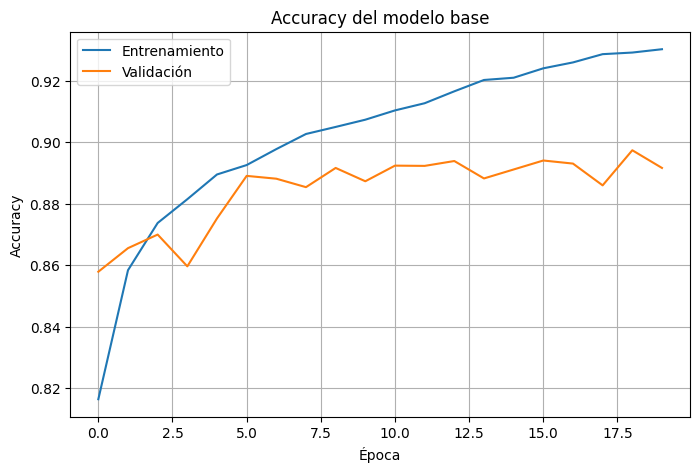

In [12]:
# Graficar accuracy de entrenamiento y validación
plt.figure(figsize=(8, 5))
plt.plot(history_base.history["accuracy"], label="Entrenamiento")
plt.plot(history_base.history["val_accuracy"], label="Validación")

plt.title("Accuracy del modelo base")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

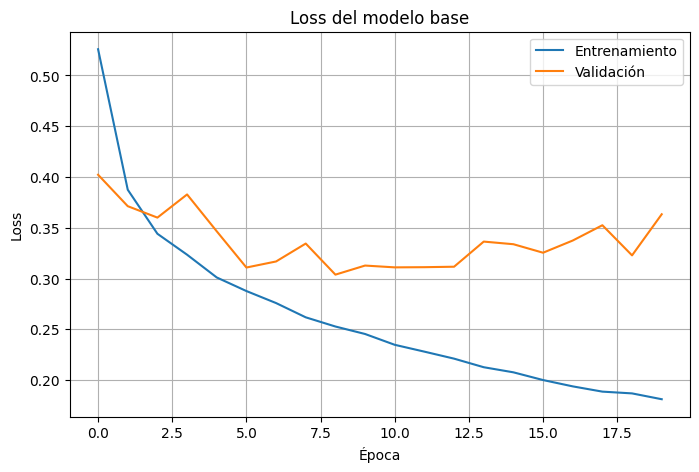

In [13]:
# Graficar loss de entrenamiento y validación
plt.figure(figsize=(8, 5))
plt.plot(history_base.history["loss"], label="Entrenamiento")
plt.plot(history_base.history["val_loss"], label="Validación")

plt.title("Loss del modelo base")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

### Análisis del modelo base

El modelo alcanza cerca de un 93% de accuracy en entrenamiento, mientras que en validación se mantiene alrededor del 89%.

En los gráficos se observa que, después de las primeras épocas, el accuracy de entrenamiento continúa aumentando, pero el de validación se mantiene relativamente estable. Algo similar ocurre con el loss: en entrenamiento sigue disminuyendo, mientras que en validación comienza a fluctuar.

Esto indica que el modelo comienza a presentar sobreajuste, ya que continúa mejorando sobre los datos de entrenamiento sin obtener una mejora equivalente en validación. Este comportamiento se tendrá en cuenta en las siguientes pruebas.